<a href="https://colab.research.google.com/github/Prateek-Dhar-Dwivedi/NLP_Practical_2026_Colab_Files/blob/main/Practical_03_NewsRoute_Explainable_Post_Routing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NewsRoute: Explainable Post Routing with Abstention and Similar-Case Retrieval
Built on the concepts of Practical 3 (BoW, TF-IDF, cosine similarity, n-grams), extended into a decision system.

**Run order:** Block 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → (optional) 13. Use *Runtime → Run all*.

**Baseline (Practical 3):** BoW/TF-IDF/cosine on 4 toy sentences.
**New here:** real labelled corpus, train/val/test discipline, classifier, confidence-based abstention, retrieval metrics, explanations.

Note: "relevant" in retrieval evaluation means *same category*. This is a proxy, not true relevance.

# NewsRoute: Explainable Post Routing with Abstention and Similar-Case Retrieval

## Overview
NewsRoute is an NLP system that reads a free-text post, predicts which of 20 categories it belongs to, and decides whether the prediction is reliable enough to act on automatically. If the model is confident, the post is **auto-routed**. Otherwise it is sent to **human review**. Each decision comes with an explanation: the words that drove the prediction and similar past posts.

## Problem Statement
Forums, help desks and moderation queues receive large volumes of posts that must reach the right team. Fully automatic routing makes costly mistakes, while fully manual routing does not scale. The goal is a system that automates the easy cases, escalates the uncertain ones, and can justify its decisions.

## Objectives
1. Compare Bag of Words, TF-IDF and TF-IDF with bigrams on a real labelled task.
2. Train an interpretable classifier that outputs class probabilities.
3. Choose a confidence threshold on validation data to reach a target accuracy, then measure coverage and accuracy on unseen test data.
4. Retrieve similar past posts using cosine similarity and evaluate with Precision@5 and MRR@10.
5. Explain each decision with evidence terms and shared terms from similar posts.

## Dataset
20 Newsgroups (about 18,000 posts across 20 topics), loaded with `sklearn.datasets.fetch_20newsgroups`. Headers, footers and quotes are removed to prevent leakage through metadata. The official train/test split is used, and a validation set is carved out of the training data.

## Pipeline
Raw post → Cleaning → TF-IDF (1–2 grams) → Logistic Regression + Cosine Retrieval → Confidence gate → Evidence terms + Similar posts → Decision

## Techniques Used
- Bag of Words, TF-IDF, n-grams (from the baseline Practical 3)
- Cosine similarity for retrieval (from the baseline Practical 3)
- Logistic Regression for probabilistic classification
- Confidence-based abstention (selective classification)
- Linear-model term contribution for explanations

## What Is New Compared to the Baseline
| Baseline (Practical 3) | This project |
|---|---|
| 4 toy sentences | About 18k real labelled posts |
| Vectors compared by eye | Measured with accuracy, macro-F1, Precision@5, MRR |
| No task | Routing decision with abstention |
| Similarity matrix | Query-time retrieval with explanations |
| No train/test split | Train/validation/test discipline |

## Evaluation
Accuracy, macro-F1, per-class report, normalized confusion matrix, coverage-vs-accuracy curve, Precision@5 and MRR@10.

## Limitations
- Retrieval "relevance" is defined as same category, which is only a proxy for true relevance.
- 20 Newsgroups is an older, English-only dataset with overlapping categories.
- Explanations show which words the model weighted, not a causal reason.
- Logistic regression probabilities may not be perfectly calibrated.

## Notebook Flow
Block 1 (Setup) → 2 (Data) → 3 (EDA) → 4 (Split) → 5 (Feature comparison) → 6 (Router) → 7 (Abstention) → 8 (Retrieval) → 9 (Routing function) → 10 (Test evaluation) → 11 (Demo) → 12 (Summary) → 13 (Optional embeddings)

### Block 1: Setup

In [3]:
# ============================================================
# BLOCK 1: SETUP, IMPORTS, SEEDS, OUTPUT FOLDER
# ============================================================
# What this block does:
# Imports every library used in the notebook, fixes random seeds,
# and creates an output directory.
#
# Why this block is needed:
# All later blocks depend on these imports and constants.
# ============================================================
import os, re, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print("Setup complete. Seed =", SEED)

Setup complete. Seed = 42


## Block 2: Load and clean data

In [4]:
# ============================================================
# BLOCK 2: LOAD AND CLEAN THE 20 NEWSGROUPS DATASET
# ============================================================
# What this block does:
# Downloads the official train/test splits, removes headers/footers/quotes
# (to prevent leakage via metadata), normalizes whitespace and drops
# near-empty posts.
#
# Why this block is needed:
# Creates train_df, test_df and CLASS_NAMES, used by all later blocks.
# Also defines clean(), reused at query time in Block 9.
# ============================================================
REMOVE_PARTS = ("headers", "footers", "quotes")

def clean(text):
    """Collapse all whitespace runs into single spaces."""
    return re.sub(r"\s+", " ", text).strip()

def load_split(subset):
    bunch = fetch_20newsgroups(subset=subset, remove=REMOVE_PARTS,
                               shuffle=True, random_state=SEED)
    df = pd.DataFrame({"text": bunch.data, "label_id": bunch.target})
    df["text"] = df["text"].map(clean)
    df["label"] = df["label_id"].map(lambda i: bunch.target_names[i])
    df["n_words"] = df["text"].str.split().str.len()
    return df, list(bunch.target_names)

train_raw, CLASS_NAMES = load_split("train")
test_raw, _ = load_split("test")

MIN_WORDS = 5
train_df = train_raw[train_raw["n_words"] >= MIN_WORDS].reset_index(drop=True)
test_df = test_raw[test_raw["n_words"] >= MIN_WORDS].reset_index(drop=True)

print(f"Train: {len(train_raw)} -> {len(train_df)} after dropping posts < {MIN_WORDS} words")
print(f"Test : {len(test_raw)} -> {len(test_df)}")
print("Classes:", len(CLASS_NAMES))

Train: 11314 -> 10904 after dropping posts < 5 words
Test : 7532 -> 7240
Classes: 20


## Block 3: EDA

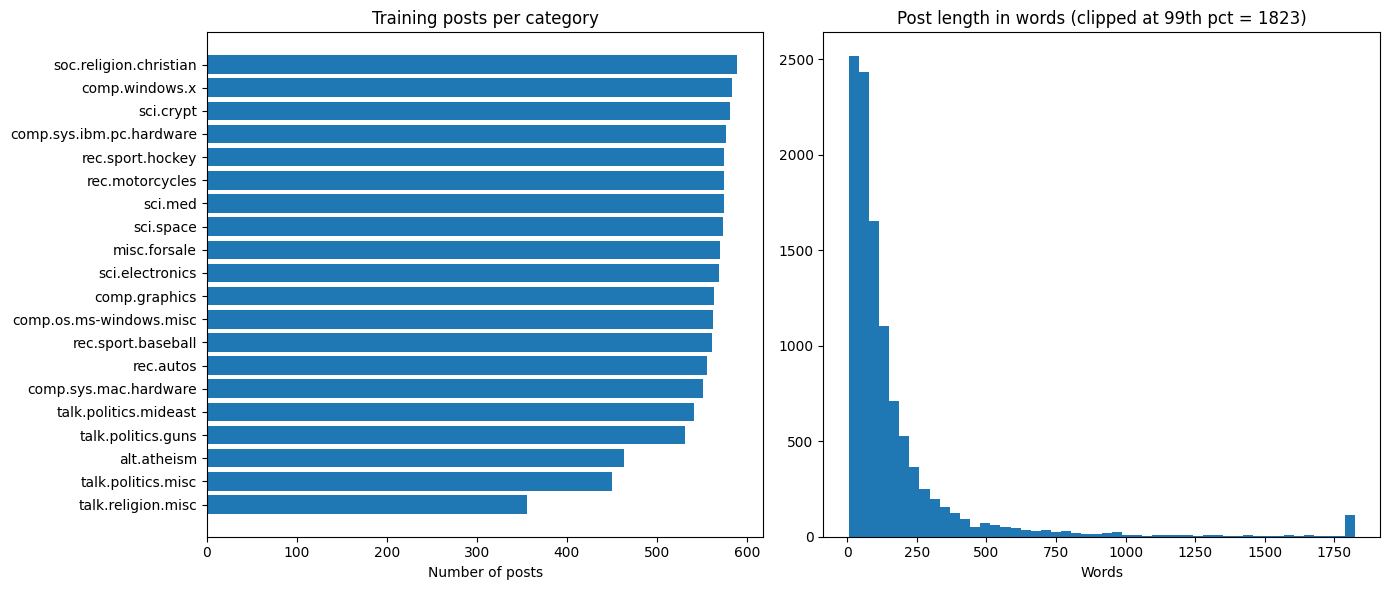

Median post length (words): 87
Largest/smallest class ratio: 1.65


In [5]:
# ============================================================
# BLOCK 3: EXPLORATORY DATA ANALYSIS
# ============================================================
# What this block does:
# Plots class balance and post-length distribution.
#
# Why this block is needed:
# Class imbalance decides whether accuracy alone is misleading (macro-F1
# is used later); post length affects how much evidence a post carries.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = train_df["label"].value_counts().sort_values()
axes[0].barh(counts.index, counts.values)
axes[0].set_title("Training posts per category")
axes[0].set_xlabel("Number of posts")

cap = train_df["n_words"].quantile(0.99)
axes[1].hist(train_df["n_words"].clip(upper=cap), bins=50)
axes[1].set_title(f"Post length in words (clipped at 99th pct = {cap:.0f})")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eda.png", dpi=120)
plt.show()

print("Median post length (words):", int(train_df["n_words"].median()))
print("Largest/smallest class ratio:", round(counts.max() / counts.min(), 2))

## Block 4: Train/validation split

In [6]:
# ============================================================
# BLOCK 4: TRAIN / VALIDATION SPLIT
# ============================================================
# What this block does:
# Splits the training set into a fitting part and a validation part.
#
# Why this block is needed:
# Feature choice and the abstention threshold must be tuned on data that is
# NOT the test set. The test set stays untouched until final reporting.
# ============================================================
fit_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df["label_id"], random_state=SEED
)
fit_df = fit_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
print(f"fit: {len(fit_df)} | val: {len(val_df)} | test: {len(test_df)}")

fit: 8723 | val: 2181 | test: 7240


## Block 5: Feature comparison

done: BoW (counts)
done: TF-IDF (unigram)
done: TF-IDF (1-2 gram)
         features  n_features  val_accuracy  val_macro_f1
     BoW (counts)       34223        0.6680        0.6614
 TF-IDF (unigram)       34223        0.7762        0.7684
TF-IDF (1-2 gram)      100000        0.7859        0.7786


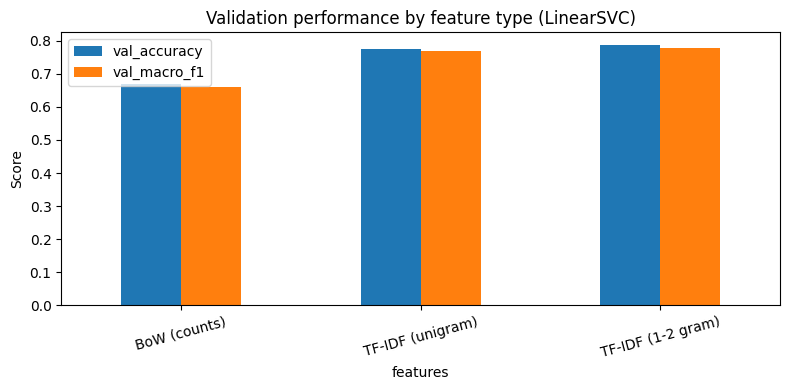

In [7]:
# ============================================================
# BLOCK 5: FEATURE COMPARISON  (BoW vs TF-IDF vs TF-IDF + bigrams)
# ============================================================
# What this block does:
# Trains the same linear classifier on three feature sets and scores them
# on the validation set.
#
# Why this block is needed:
# The baseline only claimed TF-IDF is better; this block measures it on a
# real task and justifies the feature configuration used by the router.
# ============================================================
feature_configs = {
    "BoW (counts)": CountVectorizer(stop_words="english", min_df=2, max_features=100000),
    "TF-IDF (unigram)": TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True,
                                        max_features=100000),
    "TF-IDF (1-2 gram)": TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True,
                                         ngram_range=(1, 2), max_features=100000),
}

rows = []
for name, vec in feature_configs.items():
    X_f = vec.fit_transform(fit_df["text"])
    X_v = vec.transform(val_df["text"])
    clf = LinearSVC(max_iter=5000, random_state=SEED).fit(X_f, fit_df["label_id"])
    pred = clf.predict(X_v)
    rows.append({
        "features": name,
        "n_features": X_f.shape[1],
        "val_accuracy": accuracy_score(val_df["label_id"], pred),
        "val_macro_f1": f1_score(val_df["label_id"], pred, average="macro"),
    })
    print(f"done: {name}")

comp_df = pd.DataFrame(rows).round(4)
print(comp_df.to_string(index=False))

ax = comp_df.set_index("features")[["val_accuracy", "val_macro_f1"]].plot(
    kind="bar", figsize=(8, 4), rot=15)
ax.set_title("Validation performance by feature type (LinearSVC)")
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_comparison.png", dpi=120)
plt.show()

## Block 6: Router model

In [8]:
# ============================================================
# BLOCK 6: BUILD THE ROUTER (TF-IDF 1-2gram + LOGISTIC REGRESSION)
# ============================================================
# What this block does:
# Fits the final vectorizer and a logistic regression on the fitting set,
# then computes class probabilities for validation and test posts.
#
# Why this block is needed:
# Logistic regression gives probabilities (needed for abstention) and linear
# coefficients (needed for explanations).
# ============================================================
router_vec = TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True,
                             ngram_range=(1, 2), max_features=100000)
X_fit = router_vec.fit_transform(fit_df["text"])
X_val = router_vec.transform(val_df["text"])
X_test = router_vec.transform(test_df["text"])

y_fit = fit_df["label_id"].to_numpy()
y_val = val_df["label_id"].to_numpy()
y_test = test_df["label_id"].to_numpy()

router_clf = LogisticRegression(C=20, max_iter=300, random_state=SEED)
router_clf.fit(X_fit, y_fit)

val_proba = router_clf.predict_proba(X_val)
test_proba = router_clf.predict_proba(X_test)
val_pred = val_proba.argmax(axis=1)
test_pred = test_proba.argmax(axis=1)

print("Router trained. Vocabulary size:", X_fit.shape[1])
print("Validation accuracy:", round(accuracy_score(y_val, val_pred), 4))

Router trained. Vocabulary size: 100000
Validation accuracy: 0.7808


## Block 7: Abstention

Chosen threshold (from validation): 0.43
TEST -> auto-routed: 63.3% of posts, accuracy on those: 85.9%
TEST -> sent to human review: 36.7%


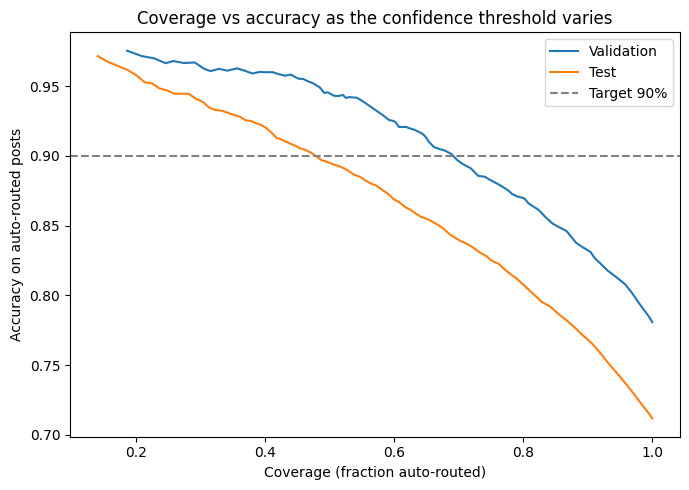

In [9]:
# ============================================================
# BLOCK 7: CONFIDENCE-BASED ABSTENTION (COVERAGE vs ACCURACY)
# ============================================================
# What this block does:
# For each confidence threshold, computes what fraction of posts would be
# auto-routed (coverage) and how accurate those are. Picks the lowest
# threshold on VALIDATION data that reaches TARGET_ACC, then applies it once
# to the test set.
#
# Why this block is needed:
# This is the decision layer: automate when confident, escalate otherwise.
# LR probabilities are not guaranteed to be calibrated; the test accuracy at
# the chosen threshold shows whether the gate really works.
# ============================================================
TARGET_ACC = 0.90

def coverage_curve(proba, y_true, thresholds):
    conf = proba.max(axis=1)
    pred = proba.argmax(axis=1)
    correct = (pred == y_true)
    rows = []
    for t in thresholds:
        keep = conf >= t
        cov = keep.mean()
        acc = correct[keep].mean() if keep.any() else np.nan
        rows.append({"threshold": t, "coverage": cov, "accuracy": acc})
    return pd.DataFrame(rows)

thresholds = np.linspace(0.05, 0.95, 91)
val_curve = coverage_curve(val_proba, y_val, thresholds)
test_curve = coverage_curve(test_proba, y_test, thresholds)

eligible = val_curve[(val_curve["accuracy"] >= TARGET_ACC) & (val_curve["coverage"] > 0)]
if len(eligible) > 0:
    AUTO_THRESHOLD = float(eligible["threshold"].min())
else:
    AUTO_THRESHOLD = 0.5
    print("Target accuracy not reachable on validation; falling back to 0.5")

test_conf = test_proba.max(axis=1)
keep_test = test_conf >= AUTO_THRESHOLD
auto_coverage_test = float(keep_test.mean())
auto_accuracy_test = float((test_pred[keep_test] == y_test[keep_test]).mean()) if keep_test.any() else float("nan")

print(f"Chosen threshold (from validation): {AUTO_THRESHOLD:.2f}")
print(f"TEST -> auto-routed: {auto_coverage_test:.1%} of posts, accuracy on those: {auto_accuracy_test:.1%}")
print(f"TEST -> sent to human review: {1 - auto_coverage_test:.1%}")

plt.figure(figsize=(7, 5))
plt.plot(val_curve["coverage"], val_curve["accuracy"], label="Validation")
plt.plot(test_curve["coverage"], test_curve["accuracy"], label="Test")
plt.axhline(TARGET_ACC, linestyle="--", color="gray", label=f"Target {TARGET_ACC:.0%}")
plt.xlabel("Coverage (fraction auto-routed)")
plt.ylabel("Accuracy on auto-routed posts")
plt.title("Coverage vs accuracy as the confidence threshold varies")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/coverage_accuracy.png", dpi=120)
plt.show()

## Block 8: Retrieval evaluation

done: BoW + cosine
done: TF-IDF unigram + cosine
done: TF-IDF 1-2gram + cosine
                 method  precision@5  MRR@10
           BoW + cosine       0.3918  0.5649
TF-IDF unigram + cosine       0.5014  0.6736
TF-IDF 1-2gram + cosine       0.4837  0.6514


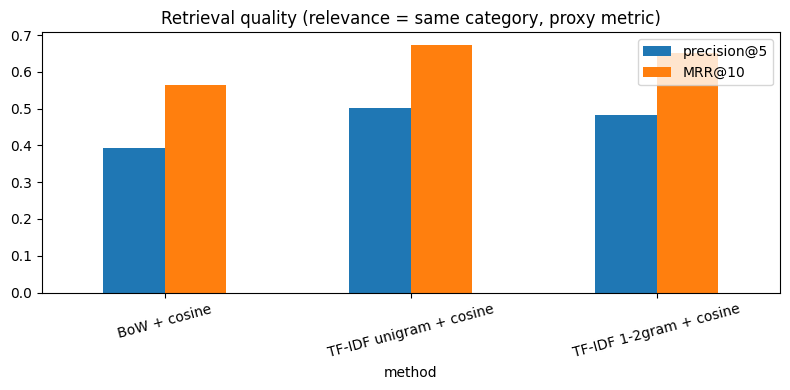

In [10]:
# ============================================================
# BLOCK 8: RETRIEVAL EVALUATION (BoW-cosine vs TF-IDF-cosine)
# ============================================================
# What this block does:
# Uses up to 2000 random test posts as queries against the whole training set
# as the pool. Measures Precision@5 and MRR@10.
#
# Why this block is needed:
# Tests the baseline's cosine-similarity idea at scale.
# IMPORTANT: "relevant" = same category, a PROXY for true relevance.
# ============================================================
query_df = test_df.sample(n=min(2000, len(test_df)), random_state=SEED).reset_index(drop=True)
y_query = query_df["label_id"].to_numpy()
y_pool_all = train_df["label_id"].to_numpy()

def topk_indices(sims, k):
    """Return indices of top-k columns per row, sorted by descending score."""
    part = np.argpartition(-sims, k, axis=1)[:, :k]
    r = np.arange(sims.shape[0])[:, None]
    return part[r, np.argsort(-sims[r, part], axis=1)]

def score_top(top, y_pool, y_q):
    """Precision@5 and reciprocal rank (over top-k) for one batch."""
    rel = (y_pool[top] == y_q[:, None])
    p5 = rel[:, :5].mean(axis=1)
    first = np.where(rel.any(axis=1), rel.argmax(axis=1) + 1, np.inf)
    return p5, 1.0 / first

def retrieval_metrics(Xq, Xp, y_q, y_pool, k=10, batch=500):
    p5_all, rr_all = [], []
    for s in range(0, Xq.shape[0], batch):
        sims = (Xq[s:s + batch] @ Xp.T).toarray()
        top = topk_indices(sims, k)
        p5, rr = score_top(top, y_pool, y_q[s:s + batch])
        p5_all.extend(p5)
        rr_all.extend(rr)
    return float(np.mean(p5_all)), float(np.mean(rr_all))

retrieval_setups = {
    "BoW + cosine": (CountVectorizer(stop_words="english", min_df=2, max_features=100000), True),
    "TF-IDF unigram + cosine": (TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True,
                                                max_features=100000), False),
    "TF-IDF 1-2gram + cosine": (TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True,
                                                ngram_range=(1, 2), max_features=100000), False),
}

retr_mats = {}
retr_rows = []
for name, (vec, needs_norm) in retrieval_setups.items():
    Xp = vec.fit_transform(train_df["text"])
    Xq = vec.transform(query_df["text"])
    if needs_norm:  # raw counts must be L2-normalized so dot product = cosine
        Xp = Normalizer().transform(Xp)
        Xq = Normalizer().transform(Xq)
    retr_mats[name] = (Xq, Xp)
    p5, mrr = retrieval_metrics(Xq, Xp, y_query, y_pool_all)
    retr_rows.append({"method": name, "precision@5": p5, "MRR@10": mrr})
    print(f"done: {name}")

retr_df = pd.DataFrame(retr_rows).round(4)
print(retr_df.to_string(index=False))

ax = retr_df.set_index("method").plot(kind="bar", figsize=(8, 4), rot=15)
ax.set_title("Retrieval quality (relevance = same category, proxy metric)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/retrieval_comparison.png", dpi=120)
plt.show()

## Block 9: The routing function

In [11]:
# ============================================================
# BLOCK 9: THE END-TO-END ROUTING FUNCTION WITH EXPLANATIONS
# ============================================================
# What this block does:
# Defines route_post(text): predicts the category, decides auto-route vs
# human review, lists the terms that pushed the prediction (coefficient x
# tf-idf value), and retrieves similar training posts with shared terms.
#
# Why this block is needed:
# This is the actual "system": classifier + confidence gate (AUTO_THRESHOLD
# from Block 7) + cosine retrieval from the baseline.
# ============================================================
feat_names = router_vec.get_feature_names_out()
pool_X = router_vec.transform(train_df["text"])   # rows are L2-normalized, so dot = cosine
pool_texts = train_df["text"].tolist()
pool_labels = train_df["label"].tolist()

def route_post(text, top_k_similar=3, n_terms=8):
    text = clean(text)
    q = router_vec.transform([text])
    if q.nnz == 0:
        return {"decision": "human_review", "reason": "no known vocabulary in post"}

    proba = router_clf.predict_proba(q)[0]
    order = np.argsort(-proba)
    best = int(order[0])
    conf = float(proba[best])
    decision = "auto_route" if conf >= AUTO_THRESHOLD else "human_review"

    # Evidence: which terms pushed the score toward the predicted class
    q_dense = q.toarray().ravel()
    contrib = q_dense * router_clf.coef_[best]
    top_idx = np.argsort(-contrib)[:n_terms]
    evidence = [(feat_names[i], round(float(contrib[i]), 3)) for i in top_idx if contrib[i] > 0]

    # Similar past posts (cosine) and the terms shared with the query
    sims = (q @ pool_X.T).toarray().ravel()
    nn = np.argsort(-sims)[:top_k_similar]
    q_terms = set(q.indices)
    similar = []
    for j in nn:
        shared = set(pool_X[j].indices) & q_terms
        shared = sorted(shared, key=lambda i: -q_dense[i])[:6]
        similar.append({
            "similarity": round(float(sims[j]), 3),
            "category": pool_labels[j],
            "shared_terms": [feat_names[i] for i in shared],
            "snippet": pool_texts[j][:160],
        })

    return {
        "decision": decision,
        "predicted_category": CLASS_NAMES[best],
        "confidence": round(conf, 3),
        "threshold": round(AUTO_THRESHOLD, 2),
        "alternatives": [(CLASS_NAMES[i], round(float(proba[i]), 3)) for i in order[1:3]],
        "evidence_terms": evidence,
        "similar_posts": similar,
    }

def print_report(result):
    print("=" * 70)
    print("DECISION  :", result["decision"].upper())
    if "reason" in result:
        print("REASON    :", result["reason"]); return
    print("CATEGORY  :", result["predicted_category"],
          f"(confidence {result['confidence']}, threshold {result['threshold']})")
    print("ALSO LIKELY:", result["alternatives"])
    print("EVIDENCE  :", result["evidence_terms"])
    print("SIMILAR POSTS:")
    for s in result["similar_posts"]:
        print(f"  [{s['similarity']}] {s['category']} | shared: {s['shared_terms']}")
        print(f"      {s['snippet']}...")

print("route_post() ready.")

route_post() ready.


## Block 10: Final test evaluation

TEST accuracy : 0.7119
TEST macro-F1 : 0.6999

                          precision    recall  f1-score   support

             alt.atheism      0.492     0.489     0.490       309
           comp.graphics      0.652     0.710     0.680       383
 comp.os.ms-windows.misc      0.633     0.653     0.643       378
comp.sys.ibm.pc.hardware      0.654     0.666     0.660       383
   comp.sys.mac.hardware      0.751     0.713     0.732       369
          comp.windows.x      0.829     0.714     0.767       381
            misc.forsale      0.784     0.805     0.794       379
               rec.autos      0.774     0.762     0.768       369
         rec.motorcycles      0.727     0.783     0.754       378
      rec.sport.baseball      0.845     0.847     0.846       373
        rec.sport.hockey      0.893     0.881     0.887       387
               sci.crypt      0.826     0.738     0.780       374
         sci.electronics      0.585     0.617     0.600       381
                 sci.med    

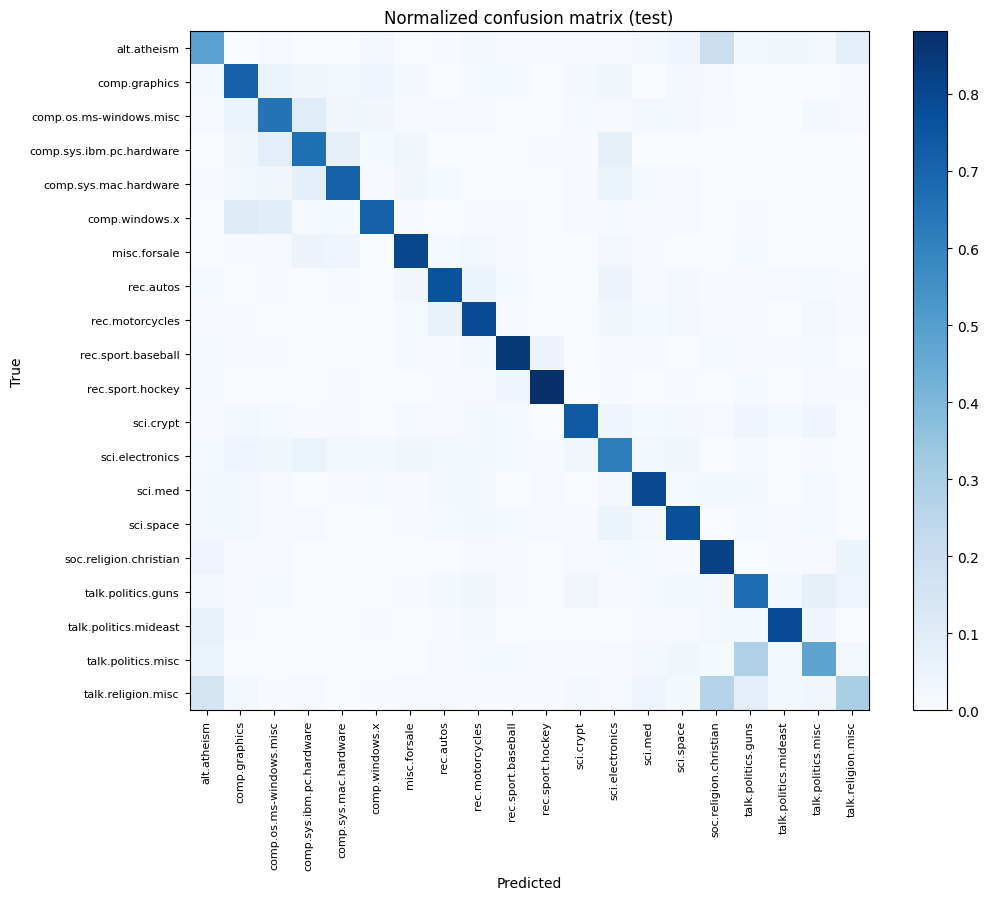

Top confused pairs (count, true -> predicted):
   85  talk.politics.misc -> talk.politics.guns
   64  talk.religion.misc -> soc.religion.christian
   61  alt.atheism -> soc.religion.christian
   41  comp.windows.x -> comp.graphics
   38  comp.os.ms-windows.misc -> comp.sys.ibm.pc.hardware
   37  talk.religion.misc -> alt.atheism
   36  comp.windows.x -> comp.os.ms-windows.misc
   34  comp.sys.ibm.pc.hardware -> comp.os.ms-windows.misc


In [12]:
# ============================================================
# BLOCK 10: FINAL TEST-SET EVALUATION AND ERROR ANALYSIS
# ============================================================
# What this block does:
# Reports accuracy and macro-F1 on the untouched test set, a per-class report,
# a normalized confusion matrix and the most confused category pairs.
#
# Why this block is needed:
# These are the headline numbers; the confusion analysis shows WHERE the
# model fails (usually semantically overlapping categories).
# ============================================================
test_acc = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")
print(f"TEST accuracy : {test_acc:.4f}")
print(f"TEST macro-F1 : {test_macro_f1:.4f}\n")
print(classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=3))

cm = confusion_matrix(y_test, test_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_norm, cmap="Blues")
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Normalized confusion matrix (test)")
fig.colorbar(im)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=120)
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)
pairs = [(off[i, j], CLASS_NAMES[i], CLASS_NAMES[j])
         for i in range(off.shape[0]) for j in range(off.shape[1]) if off[i, j] > 0]
pairs.sort(reverse=True)
print("Top confused pairs (count, true -> predicted):")
for n, a, b in pairs[:8]:
    print(f"  {n:3d}  {a} -> {b}")

## Block 11: Demo

In [13]:
# ============================================================
# BLOCK 11: DEMO ON NEW POSTS
# ============================================================
# What this block does:
# Runs route_post() on hand-written posts (one clear, one vague) and on one
# random test post with its true label shown.
#
# Why this block is needed:
# Shows the complete workflow end to end as a user would experience it.
# ============================================================
demo_posts = [
    "The new graphics card drivers keep crashing my PC when I run games at high resolution.",
    "Our team lost in overtime last night, the goalie made an incredible save in the third period.",
    "Does anyone have thoughts on this?",
]
for p in demo_posts:
    print("\nPOST:", p)
    print_report(route_post(p))

sample = test_df.sample(1, random_state=SEED).iloc[0]
print("\n\nRANDOM TEST POST (true label:", sample["label"], ")")
print(sample["text"][:300], "...")
print_report(route_post(sample["text"]))


POST: The new graphics card drivers keep crashing my PC when I run games at high resolution.
DECISION  : AUTO_ROUTE
CATEGORY  : comp.graphics (confidence 0.811, threshold 0.43)
ALSO LIKELY: [('comp.sys.ibm.pc.hardware', 0.083), ('comp.os.ms-windows.misc', 0.042)]
EVIDENCE  : [('graphics', 3.015), ('card', 0.548), ('resolution', 0.434), ('high resolution', 0.4), ('graphics card', 0.347), ('run', 0.334), ('pc', 0.323), ('high', 0.017)]
SIMILAR POSTS:
  [0.231] comp.graphics | shared: ['high resolution', 'resolution', 'pc', 'card', 'high']
      I've recently got hold of a PC with an S3 card in it, and I'd like to do some C programming with it, are there any libraries out there that will let me access t...
  [0.197] comp.graphics | shared: ['graphics card', 'graphics', 'pc', 'card']
      I am in the market for a 24-bit graphics card for a PC (ISA bus), and was wondering if anyone had any comments (good? bad? otherwise?) regarding the Diamond Ste...
  [0.18] comp.sys.ibm.pc.hardware | sh

## Block 12: Final summary

In [14]:
# ============================================================
# BLOCK 12: FINAL PROJECT SUMMARY
# ============================================================
# What this block does:
# Collects the measured results from earlier blocks, prints a summary and
# saves it to outputs/summary.json.
#
# Why this block is needed:
# Makes the notebook a complete, reproducible project. Every number below is
# computed in this run, none are hard-coded.
# ============================================================
best_feat = comp_df.sort_values("val_macro_f1", ascending=False).iloc[0]
best_retr = retr_df.sort_values("precision@5", ascending=False).iloc[0]

summary = {
    "dataset": "20 Newsgroups (headers/footers/quotes removed)",
    "n_train_fit": int(len(fit_df)), "n_val": int(len(val_df)), "n_test": int(len(test_df)),
    "best_feature_set_by_val_macro_f1": str(best_feat["features"]),
    "router_test_accuracy": round(float(test_acc), 4),
    "router_test_macro_f1": round(float(test_macro_f1), 4),
    "target_accuracy": TARGET_ACC,
    "abstention_threshold_from_validation": round(AUTO_THRESHOLD, 2),
    "test_auto_route_coverage": round(auto_coverage_test, 4),
    "test_accuracy_on_auto_routed": round(auto_accuracy_test, 4),
    "best_retrieval_method": str(best_retr["method"]),
    "best_retrieval_precision@5": float(best_retr["precision@5"]),
}
with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("NEWSROUTE: FINAL SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:40s} {v}")

print("""
KEY POINTS TO CHECK IN YOUR RUN
- Does the test accuracy on auto-routed posts reach the target?
  If not, the LR probabilities are miscalibrated; consider calibration.
- Which category pairs are most confused (Block 10)?

LIMITATIONS
- Retrieval relevance = same category (a proxy, not human judgement).
- 20 Newsgroups is old, English-only, and categories overlap.
- Explanations are linear-model term contributions, not causal.

POSSIBLE IMPROVEMENTS
- Probability calibration, sentence embeddings (Block 13), newer datasets.
""")

NEWSROUTE: FINAL SUMMARY
dataset                                  20 Newsgroups (headers/footers/quotes removed)
n_train_fit                              8723
n_val                                    2181
n_test                                   7240
best_feature_set_by_val_macro_f1         TF-IDF (1-2 gram)
router_test_accuracy                     0.7119
router_test_macro_f1                     0.6999
target_accuracy                          0.9
abstention_threshold_from_validation     0.43
test_auto_route_coverage                 0.6331
test_accuracy_on_auto_routed             0.8586
best_retrieval_method                    TF-IDF unigram + cosine
best_retrieval_precision@5               0.5014

KEY POINTS TO CHECK IN YOUR RUN
- Does the test accuracy on auto-routed posts reach the target?
  If not, the LR probabilities are miscalibrated; consider calibration.
- Which category pairs are most confused (Block 10)?

LIMITATIONS
- Retrieval relevance = same category (a proxy, not human j